In [15]:
import requests
import regex as re
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings
warnings.filterwarnings('ignore')

Problem Statement:

"Develop a data-driven travel package analysis system by scraping tour package information from TravelTriangle India. The system should collect details such as package name, destination, duration, current price, original price, discount percentage, hotel category, and package inclusions. The objective is to analyze pricing trends, identify popular destinations, compare package discounts, and generate insights that help travelers make informed travel decisions."

Objectives:
Scrape tour package data from TravelTriangle.
Clean and preprocess the collected data.
Analyze package prices and discounts.
Identify the most popular travel destinations.
Compare domestic and international package costs.
Create visualizations and dashboards for travel insights.
Provide recommendations for budget-friendly travel packages.

In [16]:
package_name=[]
duration=[]
package_type=[]
ratings=[]
discount=[]
new_prices= []
old_prices= []
cities=[]

In [26]:
for i in range(1,62):
    url=f'https://traveltriangle.com/tour-packages/Kerala/page/{i}'
    #print(url)

    response=requests.get(url)
    #print('Page:',i,response.status_code)  

    html_data=response.text
    soup=BeautifulSoup(html_data) 

    # package name
    name=soup.find_all('span',class_='fw9 m0 f16 pfc3')
    for i in name:
        package_name.append(i.text)


    # Duration
    dur=soup.find_all('span',class_='iblock sfc6')
    for i in dur:
        duration.append(i.text)
    

    # Package Type
    type=soup.find_all('span',class_='pfc4 iblock')
    for i in type:
        package_type.append(i.text)
    

    # Ratings
    rat=soup.find_all('label',class_='pr0 pt0 pl20')
    for i in rat:
        ratings.append(i.text)
    

    # Discount
    dis=soup.find_all('span',class_='f12 fw4 pt2 pb2 pl8 pr8 radius20 pbc1 sfcw at_discount_label')
    for i in dis:
        discount.append(i.text)


    # Prices
    for p in soup.find_all('p', class_='priceVal'):

    # New Price
        new_price = re.sub(r'[^0-9]', '', p.contents[0])
        new_prices.append(int(new_price))

    # Old Price
        old_tag = p.find('span', class_='at_oldprice')

        if old_tag:
            old_price = re.sub(r'[^0-9]', '', old_tag.text)
            old_prices.append(int(old_price))
        else:
            old_prices.append(None)


    # Cities
    city=soup.find_all('ul',class_='clearfix package-cities-list at_packagecity_list')
    for i in city:
        cities.append(i.text)


In [27]:
print(package_name)
print('*'*1000)
print(duration)
print('*'*1000)
print(package_type)
print('*'*1000)
print(ratings)
print('*'*1000)
print(discount)
print('*'*1000)
print(new_prices)
print('*'*1000)
print(old_prices)
print('*'*1000)
print(cities)

['Alleppey-Munnar Kerala Weekend Tour ', 'Charismatic Kochi Tour Package', 'Hills & Houseboat: Munnar and Alleppey Honeymoon Package ', 'Vibrant Kochi Munnar Honeymoon Tour Package', 'Mesmerizing Getaway To Kochi', 'Kerala Wayanad Weekend Holiday', 'Trip To Mesmerising Munnar ', 'Best Selling Kerala Honeymoon Tour Package', 'Catch The Beauty Of The Setting Sun In Alleppey', 'Best Selling Kerala Houseboat & Jungle Safari Tour Package', 'Charming Alleppey Honeymoon Package', 'A Blissful Tour In Munnar', 'Top 5 Nights 6 Days Kerala Family Tour Packages For A Refreshing Getaway', 'Exploring Godâ\x80\x99s Own Country, Kerala', 'Reasonable Munnar Thekkady Alleppey Honeymoon Packages', 'Ecstatic Athirapally Tour Package', 'Mesmerizing Kerala Holiday: Weekend in Munnar & Thekkady', 'Captivating Thekkady Honeymoon Package', 'A Surreal Escape To Mesmerising Destinations', 'Visit Kerala And See Astounding Places', 'Exclusive Kerala Munnar Tour Packages for an Amazing Vacation', 'Exciting Athirapa

In [30]:
print(len(package_name))
print(len(duration))
print(len(package_type))
print(len(ratings))
print(len(discount))
print(len(new_prices))
print(len(old_prices))
print(len(cities))

2400
2400
2400
2400
2400
2400
2400
2400


In [29]:
package_name=package_name[:2400]
duration=duration[:2400]
package_type=package_type[:2400]
ratings=ratings[:2400]
discount=discount[:2400]
new_prices=new_prices[:2400]
old_prices=old_prices[:2400]
cities=cities[:2400]

In [31]:
df=pd.DataFrame({'Package Name':package_name,
                'Package Type':package_type,
                'Duration':duration,
                'Ratings':ratings,
                'Discount':discount,
                'New Prices':new_prices,
                'Old Prices':old_prices,
                'Cities':cities})

In [32]:
df

,Package Name,Package Type,Duration,Ratings,Discount,New Prices,Old Prices,Cities
0,Alleppey-Munnar Kerala Weekend Tour,Customizable,4 Days & 3 Nights,3 Star,24% Off,13020,17132.0,Munnar (2D)Alleppey (2D)
1,Charismatic Kochi Tour Package,Customizable,4 Days & 3 Nights,4 Star,9% Off,15000,16484.0,Kochi (1D)Munnar (3D)
2,Hills & Houseboat: Munnar and Alleppey Honeymo...,Customizable,6 Days & 5 Nights,5 Star,10% Off,22000,24444.0,Munnar (2D)Thekkady (1D)Alleppey (1D)Kochi (2D)
3,Vibrant Kochi Munnar Honeymoon Tour Package,Customizable,4 Days & 3 Nights,3 Star,10% Off,14571,16190.0,Cochin (1D)Munnar (3D)
4,Mesmerizing Getaway To Kochi,Customizable,2 Days & 1 Nights,3 Star,9% Off,4800,5275.0,Kochi (2D)
...,...,...,...,...,...,...,...,...
2395,5-Day Scenic Kerala Tour with Houseboat Stay,Customizable,5 Days & 4 Nights,4 Star,15% Off,46612,54200.0,Munnar (2D)Thekkady (1D)Alleppey (1D)Cochin (1D)
2396,"5-Day Kerala Tour with Munnar, Thekkady & Alle...",Customizable,5 Days & 4 Nights,3 Star,12% Off,57728,65600.0,Munnar (2D)Thekkady (1D)Alleppey (1D)Cochin (1D)
2397,4-Day Romantic Kerala Tour with Houseboat Stay,Customizable,4 Days & 3 Nights,3 Star,13% Off,38715,44500.0,Munnar (2D)Alleppey (1D)Kochi (1D)
2398,"Enchanting 5-Day Kerala Tour Covering Munnar, ...",Customizable,5 Days & 4 Nights,3 Star,9% Off,40095,44550.0,Munnar (2D)Thekkady (1D)Alleppey (1D)Kochi (1D)


In [33]:
df['Discount'] = df['Discount'].str.extract(r'(\d+%)')

In [34]:
def split_cities(city_string):

    matches = re.findall(r'([^→]+?)\s*\((\d+)D\)', city_string)

    one_day = []
    two_day = []
    three_day = []

    for city, day in matches:
        city = city.strip()

        if day == '1':
            one_day.append(city)
        elif day == '2':
            two_day.append(city)
        elif day == '3':
            three_day.append(city)

    return pd.Series([
        ', '.join(one_day),
        ', '.join(two_day),
        ', '.join(three_day)
    ])

df[['1D Cities', '2D Cities', '3D Cities']] = df['Cities'].apply(split_cities)

In [35]:
df

,Package Name,Package Type,Duration,Ratings,Discount,New Prices,Old Prices,Cities,1D Cities,2D Cities,3D Cities
0,Alleppey-Munnar Kerala Weekend Tour,Customizable,4 Days & 3 Nights,3 Star,24%,13020,17132.0,Munnar (2D)Alleppey (2D),,"Munnar, Alleppey",
1,Charismatic Kochi Tour Package,Customizable,4 Days & 3 Nights,4 Star,9%,15000,16484.0,Kochi (1D)Munnar (3D),Kochi,,Munnar
2,Hills & Houseboat: Munnar and Alleppey Honeymo...,Customizable,6 Days & 5 Nights,5 Star,10%,22000,24444.0,Munnar (2D)Thekkady (1D)Alleppey (1D)Kochi (2D),"Thekkady, Alleppey","Munnar, Kochi",
3,Vibrant Kochi Munnar Honeymoon Tour Package,Customizable,4 Days & 3 Nights,3 Star,10%,14571,16190.0,Cochin (1D)Munnar (3D),Cochin,,Munnar
4,Mesmerizing Getaway To Kochi,Customizable,2 Days & 1 Nights,3 Star,9%,4800,5275.0,Kochi (2D),,Kochi,
...,...,...,...,...,...,...,...,...,...,...,...
2395,5-Day Scenic Kerala Tour with Houseboat Stay,Customizable,5 Days & 4 Nights,4 Star,15%,46612,54200.0,Munnar (2D)Thekkady (1D)Alleppey (1D)Cochin (1D),"Thekkady, Alleppey, Cochin",Munnar,
2396,"5-Day Kerala Tour with Munnar, Thekkady & Alle...",Customizable,5 Days & 4 Nights,3 Star,12%,57728,65600.0,Munnar (2D)Thekkady (1D)Alleppey (1D)Cochin (1D),"Thekkady, Alleppey, Cochin",Munnar,
2397,4-Day Romantic Kerala Tour with Houseboat Stay,Customizable,4 Days & 3 Nights,3 Star,13%,38715,44500.0,Munnar (2D)Alleppey (1D)Kochi (1D),"Alleppey, Kochi",Munnar,
2398,"Enchanting 5-Day Kerala Tour Covering Munnar, ...",Customizable,5 Days & 4 Nights,3 Star,9%,40095,44550.0,Munnar (2D)Thekkady (1D)Alleppey (1D)Kochi (1D),"Thekkady, Alleppey, Kochi",Munnar,


In [36]:
df.shape

(2400, 11)

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Package Name  2400 non-null   object 
 1   Package Type  2400 non-null   object 
 2   Duration      2400 non-null   object 
 3   Ratings       2400 non-null   object 
 4   Discount      2400 non-null   object 
 5   New Prices    2400 non-null   int64  
 6   Old Prices    2396 non-null   float64
 7   Cities        2400 non-null   object 
 8   1D Cities     2400 non-null   object 
 9   2D Cities     2400 non-null   object 
 10  3D Cities     2400 non-null   object 
dtypes: float64(1), int64(1), object(9)
memory usage: 206.4+ KB


In [38]:
df.drop(columns='Cities')

,Package Name,Package Type,Duration,Ratings,Discount,New Prices,Old Prices,1D Cities,2D Cities,3D Cities
0,Alleppey-Munnar Kerala Weekend Tour,Customizable,4 Days & 3 Nights,3 Star,24%,13020,17132.0,,"Munnar, Alleppey",
1,Charismatic Kochi Tour Package,Customizable,4 Days & 3 Nights,4 Star,9%,15000,16484.0,Kochi,,Munnar
2,Hills & Houseboat: Munnar and Alleppey Honeymo...,Customizable,6 Days & 5 Nights,5 Star,10%,22000,24444.0,"Thekkady, Alleppey","Munnar, Kochi",
3,Vibrant Kochi Munnar Honeymoon Tour Package,Customizable,4 Days & 3 Nights,3 Star,10%,14571,16190.0,Cochin,,Munnar
4,Mesmerizing Getaway To Kochi,Customizable,2 Days & 1 Nights,3 Star,9%,4800,5275.0,,Kochi,
...,...,...,...,...,...,...,...,...,...,...
2395,5-Day Scenic Kerala Tour with Houseboat Stay,Customizable,5 Days & 4 Nights,4 Star,15%,46612,54200.0,"Thekkady, Alleppey, Cochin",Munnar,
2396,"5-Day Kerala Tour with Munnar, Thekkady & Alle...",Customizable,5 Days & 4 Nights,3 Star,12%,57728,65600.0,"Thekkady, Alleppey, Cochin",Munnar,
2397,4-Day Romantic Kerala Tour with Houseboat Stay,Customizable,4 Days & 3 Nights,3 Star,13%,38715,44500.0,"Alleppey, Kochi",Munnar,
2398,"Enchanting 5-Day Kerala Tour Covering Munnar, ...",Customizable,5 Days & 4 Nights,3 Star,9%,40095,44550.0,"Thekkady, Alleppey, Kochi",Munnar,


In [39]:
df.isnull().sum()

Package Name    0
Package Type    0
Duration        0
Ratings         0
Discount        0
New Prices      0
Old Prices      4
Cities          0
1D Cities       0
2D Cities       0
3D Cities       0
dtype: int64

In [40]:
df['Old Prices']=df['Old Prices'].fillna(df['Old Prices'].mean())

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Package Name  2400 non-null   object 
 1   Package Type  2400 non-null   object 
 2   Duration      2400 non-null   object 
 3   Ratings       2400 non-null   object 
 4   Discount      2400 non-null   object 
 5   New Prices    2400 non-null   int64  
 6   Old Prices    2400 non-null   float64
 7   Cities        2400 non-null   object 
 8   1D Cities     2400 non-null   object 
 9   2D Cities     2400 non-null   object 
 10  3D Cities     2400 non-null   object 
dtypes: float64(1), int64(1), object(9)
memory usage: 206.4+ KB


In [42]:
df.describe()

,New Prices,Old Prices
count,2400.000000,2400.000000
mean,29772.775417,33534.360184
std,22666.634207,25619.707416
min,3324.000000,3613.000000
25%,14900.000000,16906.750000
50%,23904.000000,26985.000000
75%,37128.000000,42000.000000
max,197580.000000,222000.000000


Data Visualization

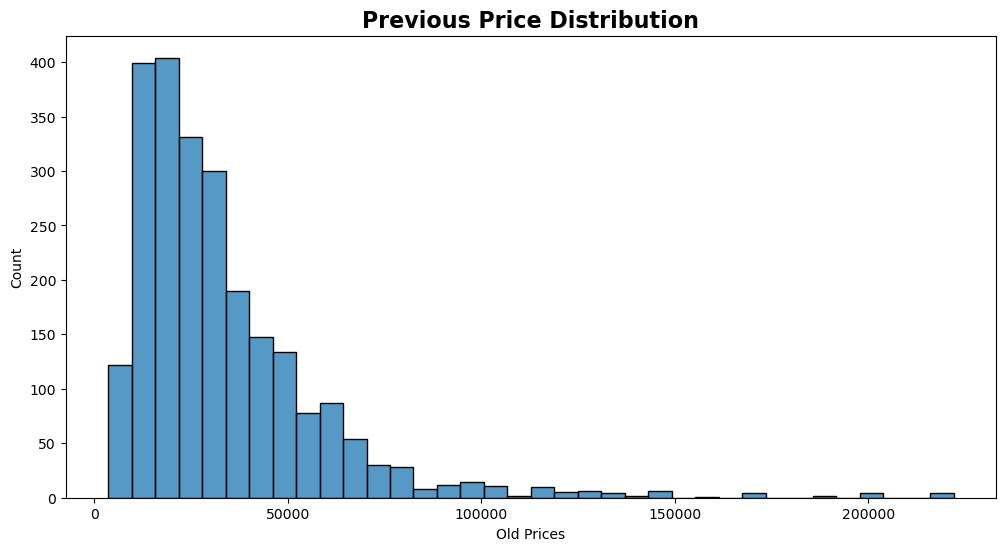

In [59]:
# Price Visualization
plt.figure(figsize=(12,6))
sns.histplot(df,x='Old Prices',bins=36)
plt.title('Previous Price Distribution',fontsize=16, fontweight='bold')
plt.show()

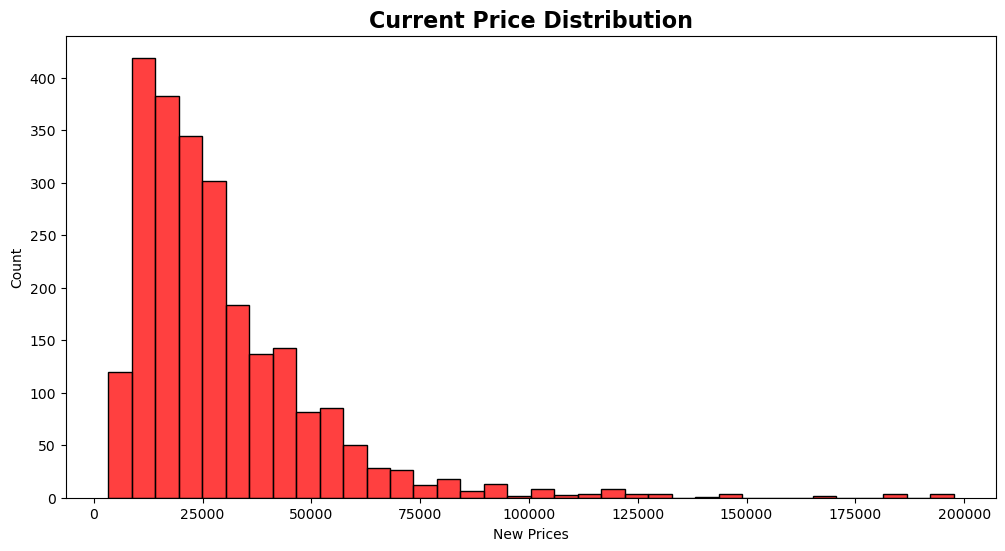

In [60]:
# Price Visualization
plt.figure(figsize=(12,6))
sns.histplot(df,x='New Prices',bins=36,color='red')
plt.title('Current Price Distribution',fontsize=16, fontweight='bold')
plt.show()

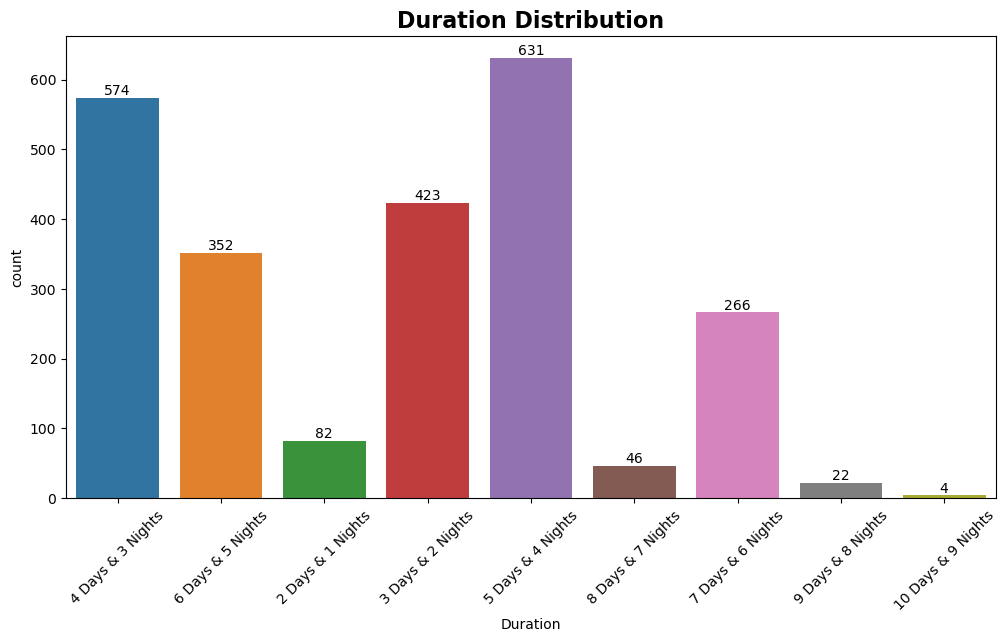

In [61]:
# Duration Visualization
plt.figure(figsize=(12,6))
ax = sns.countplot(data=df, x='Duration', palette='tab10')

for container in ax.containers:
    ax.bar_label(container)

plt.xticks(rotation=45)
plt.title('Duration Distribution',fontsize=16, fontweight='bold')
plt.show()

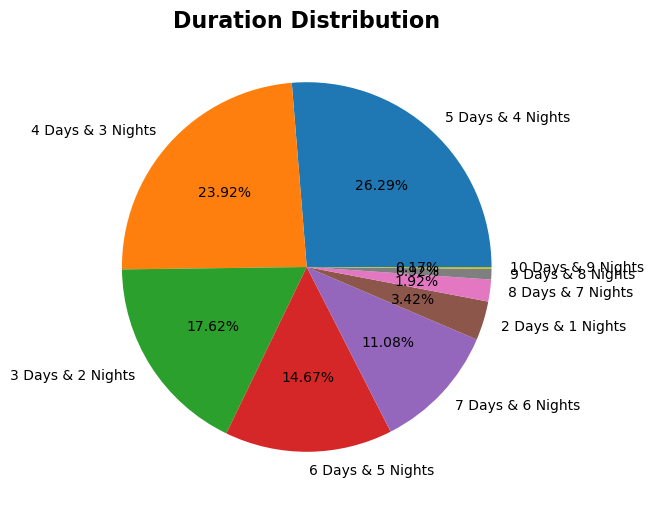

In [62]:
# Duration Visualization
plt.figure(figsize=(12,6))
dur_counts=df['Duration'].value_counts()
plt.pie(dur_counts.values,
        labels=dur_counts.index,
        autopct='%0.2f%%')
plt.title('Duration Distribution',fontsize=16, fontweight='bold')
plt.show()

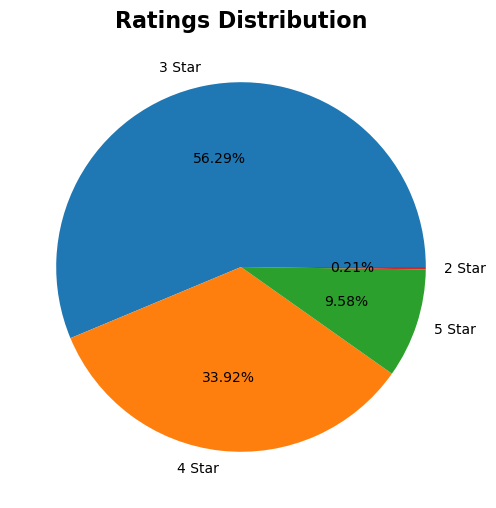

In [63]:
# Ratings 
plt.figure(figsize=(12,6))
dur_counts=df['Ratings'].value_counts()
plt.pie(dur_counts.values,
        labels=dur_counts.index,
        autopct='%0.2f%%')
plt.title('Ratings Distribution',fontsize=16, fontweight='bold')
plt.show()

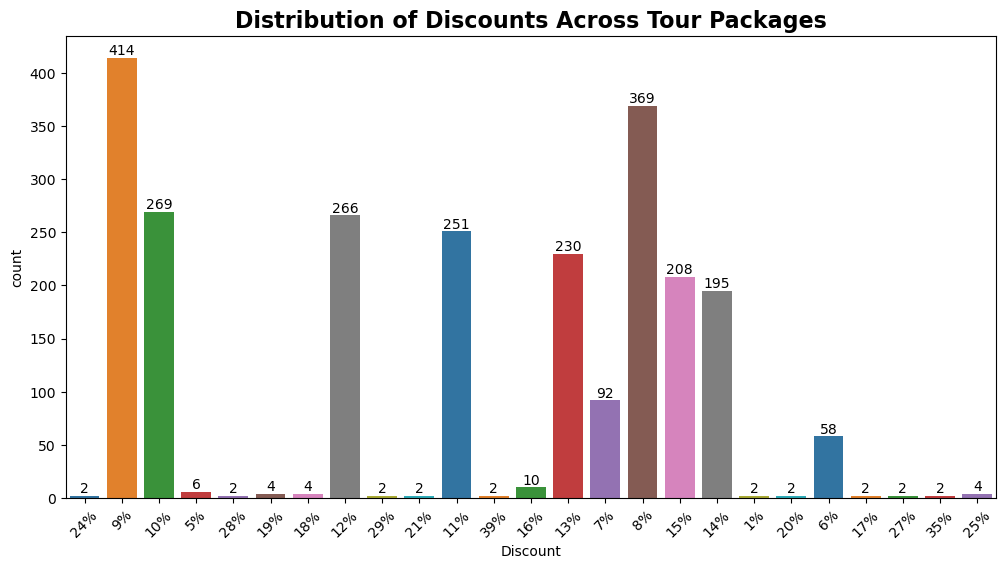

In [64]:
# Discounts
plt.figure(figsize=(12,6))
ax = sns.countplot(data=df, x='Discount', palette='tab10')

for container in ax.containers:
    ax.bar_label(container)

plt.xticks(rotation=45)
plt.title('Distribution of Discounts Across Tour Packages',
          fontsize=16, fontweight='bold')
plt.show()

<Figure size 800x600 with 0 Axes>

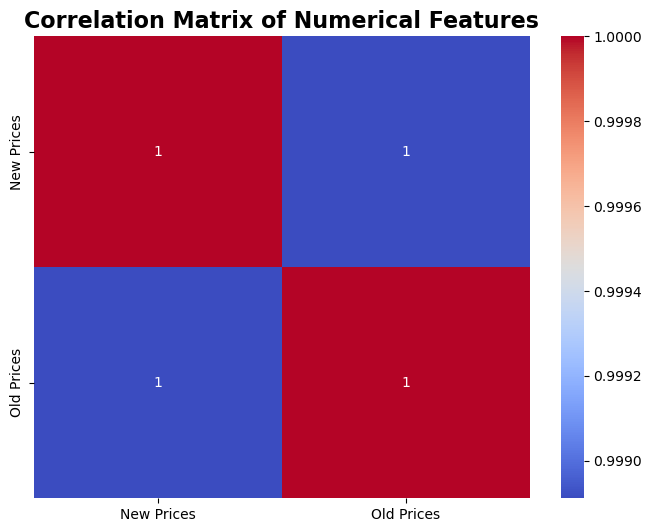

In [65]:
# Correlation Matrix of Numerical Features
plt.figure(figsize=(8,6))
num=df.select_dtypes(include=['int64','float64'])
plt.figure(figsize=(8,6))
sns.heatmap(num.corr(),annot=True,cmap='coolwarm')
plt.title('Correlation Matrix of Numerical Features',
          fontsize=16,
          fontweight='bold')
plt.show()